# Concrete Beam Section Calculation

## Set-Based Design Analysis

This notebook provides tools for analyzing reinforced concrete beam sections using set-based design methodology.

## 1. Import Libraries

# Import the main Python tools used in the notebook

This first code block prepares the notebook environment.

It imports:
- `numpy` for numerical calculations
- `pandas` for handling tables and dataframes
- `matplotlib` for plotting figures
- `scipy.optimize` for numerical methods, if needed later

It also suppresses warning messages so the notebook output becomes cleaner and easier to read.

Finally, the plotting style is set and `%matplotlib inline` is activated so that all figures are shown directly inside the notebook.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Define material properties for concrete and reinforcement steel

This code block introduces the basic design parameters for the beam sections.

It defines:
- concrete strength values
- steel strength values
- safety factors for concrete and steel
- the resulting design strengths used in resistance calculations

It also sets geometric assumptions related to reinforcement, such as:
- concrete cover
- available bar diameters
- number of reinforcement layers
- stirrup diameter

At the end, the block prints the most important design values so we can verify that the material model is set up correctly before continuing.

In [52]:
# Concrete properties
fc = 30  # Concrete compressive strength (MPa)
fck = 25  # Characteristic compressive strength (MPa)
gamma_c = 1.5  # Safety factor for concrete
fcd = fck / gamma_c  # Design compressive strength (MPa)

# Steel reinforcement properties
fy = 500  # Yield strength of steel (MPa)
fyk = 500  # Characteristic yield strength (MPa)
gamma_s = 1.15  # Safety factor for steel
fyd = fyk / gamma_s  # Design yield strength (MPa)

concrete_cover = [35]                  #Concrete cover in [mm]
Rebar_size_s = [16,20,25]  
Rebar_size_prim = Rebar_size_s
n_rebar_layers = [1]
Stirrups_Size = 12 

# Concrete strain at crushing
epsilon_cu = 0.0035  # Concrete ultimate strain
epsilon_y = fyd / (200000)  # Steel yield strain

print(f"Design concrete strength (fcd): {fcd:.2f} MPa")
print(f"Design steel strength (fyd): {fyd:.2f} MPa")
print(f"Steel yield strain: {epsilon_y:.6f}")

Design concrete strength (fcd): 16.67 MPa
Design steel strength (fyd): 434.78 MPa
Steel yield strain: 0.002174


## Generation of reinforcement layout and concrete rectangular section

# Calculate the minimum clear spacing between reinforcement bars

This block determines the minimum allowed spacing between bars according to a simplified Eurocode-inspired rule.

For each available bar diameter, the code compares different spacing requirements and chooses the governing minimum value. It then rounds that value up to the nearest 5 mm.

This is important because the spacing between bars affects:
- whether the reinforcement can be placed in practice
- whether concrete can be properly cast around the bars
- the final section width of the beam

The result is stored in a dictionary so it can be reused when building reinforcement layouts later in the notebook.

In [53]:
# -----------------------------------------
# EC2 minimum spacing ONLY (rounded up to 5 mm)
# -----------------------------------------

max_aggregate_size = 16  # mm

spacing_values = {}

for phi in Rebar_size_s:

    # EC2 minimum clear spacing
    s_min_raw = max(phi, 20, max_aggregate_size + 5)

    # Round UP to nearest 5 mm
    s_min = int(np.ceil(s_min_raw / 5.0) * 5)

    spacing_values[phi] = s_min

print("Minimum EC2 spacing per diameter:")
for k, v in spacing_values.items():
    print(f"Ø{k} → {v} mm")


Minimum EC2 spacing per diameter:
Ø16 → 25 mm
Ø20 → 25 mm
Ø25 → 25 mm


## Generate possible reinforcement layout combinations

This code block builds a set of reinforcement configurations that will later be combined with beam heights and reinforcement counts.

For each allowed layout, the code stores information such as:
- number of reinforcement layers
- bar diameter in each layer
- spacing between bars
- concrete cover
- stirrup size
- material class

At this stage, the goal is not yet to calculate structural capacity. Instead, the purpose is to create a structured list of design alternatives that can be explored systematically in the next steps.

The final result is turned into a dataframe so it is easy to inspect and use in later calculations.

In [55]:
final_combinations = []
comb_id = 1
concrete_class = [fyd]

for n_layers in n_rebar_layers:

    # -------- 1 Layer --------
    if n_layers == 1:
        for si1 in Rebar_size_s:

            sp1 = spacing_values[si1]   # <-- spacing assigned here

            for si_prim in [p for p in Rebar_size_prim if p == si1]:
                for con_c in concrete_cover:
                    for c in concrete_class:

                        comb = {
                            "Combination name": comb_id,
                            "no layers rebar": n_layers,
                            "Spacing layer 1": sp1,
                            "Spacing layer 2": "",
                            "Size layer 1": si1,
                            "Size layer 2": "",
                            "Concrete class": c,
                            "Concrete cover": con_c,
                            "Stirrup size": Stirrups_Size,
                        }

                        final_combinations.append(comb)
                        comb_id += 1

    # -------- 2 Layers --------
    elif n_layers == 2:
        for si1 in Rebar_size_s:
            for si2 in [si1]:

                sp1 = spacing_values[si1]
                sp2 = spacing_values[si2]

                for si_prim in [p for p in Rebar_size_prim if p == si1]:
                    for con_c in concrete_cover:
                        for c in concrete_class:

                            comb = {
                                "Combination name": comb_id,
                                "no layers rebar": n_layers,
                                "Spacing layer 1": sp1,
                                "Spacing layer 2": sp2,
                                "Size layer 1": si1,
                                "Size layer 2": si2,
                                "Concrete class": c,
                                "Concrete cover": con_c,
                                "Stirrup size": Stirrups_Size,
                            }

                            final_combinations.append(comb)
                            comb_id += 1

# ----------------------------
# Display / print results
# ----------------------------
print(f"Number of combinations: {len(final_combinations)}")
#print("spacing =", spacing)
df = pd.DataFrame(final_combinations)
df


Number of combinations: 3


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size
0,1,1,25,,16,,434.782609,35,12
1,2,1,25,,20,,434.782609,35,12
2,3,1,25,,25,,434.782609,35,12


## Generate beam sections from the reinforcement layouts

This block expands the reinforcement layouts into full beam-section alternatives.

For each reinforcement combination, it varies:
- the total section height
- the number of bars in layer 1
- the number of bars in layer 2 -  we dont use this in this example

For every alternative, the code calculates:
- section width
- reinforcement area in each layer
- effective depth to the reinforcement
- a unique section identifier

This is an important step in the set-based design process, because it creates the larger design space that will later be checked for flexural capacity, shear capacity, cost, and CO2 impact.

In [56]:
import numpy as np
import pandas as pd

# -------------------------------------------------
# New parameters for section sizing / reinforcement count
# -------------------------------------------------
section_height  = np.linspace(200, 500, 50)  # [mm]
rebars_layer_1  = [2, 3, 4]
rebars_layer_2  = [2]

# -------------------------------------------------
# Build "concrete_section" by combining:
# - each item in final_combinations
# - each section_height
# - each rebars_layer_1 / rebars_layer_2
# and computing width + effective heights + rebar areas
# -------------------------------------------------
concrete_section = []
sec_id = 1

for comb in final_combinations:
    cover = float(comb["Concrete cover"])

    # Sizes might be '' for 1-layer cases -> handle cleanly
    size1 = float(comb["Size layer 1"]) if comb["Size layer 1"] != "" else np.nan
    size2 = float(comb["Size layer 2"]) if comb["Size layer 2"] != "" else np.nan

    sp1 = float(comb["Spacing layer 1"]) if comb["Spacing layer 1"] != "" else np.nan
    sp2 = float(comb["Spacing layer 2"]) if comb["Spacing layer 2"] != "" else np.nan

    n_layers = int(comb["no layers rebar"])

    for h in section_height:
        for n1 in rebars_layer_1:
            for n2 in rebars_layer_2:

                # ----------------------------
                # Width (based on layer 1, per your formula)
                # width = cover + size1*n1 + sp1*(n1-1) + cover
                # ----------------------------
                width = cover + size1 * n1 + sp1 * (n1 - 1) + cover

                # ----------------------------
                # Rebar areas
                # ----------------------------
                rebar_area_layer_1 = np.pi * (size1 ** 2) / 4.0 * n1

                if n_layers >= 2 and not np.isnan(size2):
                    rebar_area_layer_2 = np.pi * (size2 ** 2) / 4.0 * n2
                else:
                    rebar_area_layer_2 = 0.0

                # ----------------------------
                # Effective height to layer 1 (given)
                # d1 = h - cover - size1/2
                # ----------------------------
                effective_height_layer_1 = h - cover - (size1 / 2.0)

                # Optional: effective height to layer 2 if present
                # Assumption: layer 2 sits above layer 1 by (size1/2 + clear gap + size2/2)
                # If you have a specific vertical clear spacing rule, replace `vertical_clear_gap`.
                vertical_clear_gap = 0.0
                if n_layers >= 2 and not np.isnan(size2):
                    effective_height_layer_2 = h - cover - size1 - vertical_clear_gap - (size2 / 2.0)
                else:
                    effective_height_layer_2 = np.nan

                # Store: original combination + new section info
                row = dict(comb)  # copy everything from final_combinations
                row.update({
                    "Section ID": sec_id,
                    "Section height": float(h),
                    "n rebars layer 1": int(n1),
                    "n rebars layer 2": int(n2) if n_layers >= 2 else 0,
                    "Section width": float(width),
                    "As layer 1": float(rebar_area_layer_1),
                    "As layer 2": float(rebar_area_layer_2),
                    "Effective height layer 1": float(effective_height_layer_1),
                    "Effective height layer 2": float(effective_height_layer_2) if not np.isnan(effective_height_layer_2) else np.nan,
                })

                concrete_section.append(row)
                sec_id += 1

# -------------------------------------------------
# View as DataFrame in Jupyter
# -------------------------------------------------
df_section = pd.DataFrame(concrete_section)
print(f"Number of concrete sections: {len(df_section)}")
df_section


Number of concrete sections: 450


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Section ID,Section height,n rebars layer 1,n rebars layer 2,Section width,As layer 1,As layer 2,Effective height layer 1,Effective height layer 2
0,1,1,25,,16,,434.782609,35,12,1,200.000000,2,0,127.0,402.123860,0.0,157.000000,NaN
1,1,1,25,,16,,434.782609,35,12,2,200.000000,3,0,168.0,603.185789,0.0,157.000000,NaN
2,1,1,25,,16,,434.782609,35,12,3,200.000000,4,0,209.0,804.247719,0.0,157.000000,NaN
3,1,1,25,,16,,434.782609,35,12,4,206.122449,2,0,127.0,402.123860,0.0,163.122449,NaN
4,1,1,25,,16,,434.782609,35,12,5,206.122449,3,0,168.0,603.185789,0.0,163.122449,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,3,1,25,,25,,434.782609,35,12,446,493.877551,3,0,195.0,1472.621556,0.0,446.377551,NaN
446,3,1,25,,25,,434.782609,35,12,447,493.877551,4,0,245.0,1963.495408,0.0,446.377551,NaN
447,3,1,25,,25,,434.782609,35,12,448,500.000000,2,0,145.0,981.747704,0.0,452.500000,NaN
448,3,1,25,,25,,434.782609,35,12,449,500.000000,3,0,195.0,1472.621556,0.0,452.500000,NaN


## For simplifying we reduce the initial set to include sections with 1 layer of rebars. 

Keep only sections with one reinforcement layer

This code block simplifies the design set by selecting only beam sections with a single layer of tensile reinforcement.

It also removes columns that are only relevant for two-layer reinforcement layouts, such as:
- second-layer bar size
- second-layer spacing
- second-layer reinforcement area
- second-layer effective depth

This makes the dataframe cleaner and easier to work with in the following structural calculations, where the flexural resistance is treated as a singly reinforced section.

In [57]:
# ---------------------------------------
# Keep only sections with 1 rebar layer
# ---------------------------------------
df_section_1_layer = df_section[df_section["no layers rebar"] == 1].copy()



df_section_1_layer = df_section_1_layer.drop(
    columns=[
        "Size layer 2",
        "Spacing layer 2",
        "As layer 2",
        "Effective height layer 2",
        "n rebars layer 2"
    ],
    errors="ignore"
)

print(f"Number of 1-layer concrete sections: {len(df_section_1_layer)}")
df_section_1_layer


Number of 1-layer concrete sections: 450


,Combination name,no layers rebar,Spacing layer 1,Size layer 1,Concrete class,Concrete cover,Stirrup size,Section ID,Section height,n rebars layer 1,Section width,As layer 1,Effective height layer 1
0,1,1,25,16,434.782609,35,12,1,200.000000,2,127.0,402.123860,157.000000
1,1,1,25,16,434.782609,35,12,2,200.000000,3,168.0,603.185789,157.000000
2,1,1,25,16,434.782609,35,12,3,200.000000,4,209.0,804.247719,157.000000
3,1,1,25,16,434.782609,35,12,4,206.122449,2,127.0,402.123860,163.122449
4,1,1,25,16,434.782609,35,12,5,206.122449,3,168.0,603.185789,163.122449
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,3,1,25,25,434.782609,35,12,446,493.877551,3,195.0,1472.621556,446.377551
446,3,1,25,25,434.782609,35,12,447,493.877551,4,245.0,1963.495408,446.377551
447,3,1,25,25,434.782609,35,12,448,500.000000,2,145.0,981.747704,452.500000
448,3,1,25,25,434.782609,35,12,449,500.000000,3,195.0,1472.621556,452.500000


## Define flexural capacity functions and calculate moment resistance

This code block introduces the main formulas used to evaluate the bending resistance of the beam sections.

The functions calculate:
- the neutral axis depth from force equilibrium
- the lever arm between compression and tension resultants
- the flexural moment capacity
- a simple classification of the section behavior

Then, for each beam section, the code computes the most important bending-related quantities and stores them in a new dataframe called `sectional_capacity`.

This is the first major structural evaluation step in the notebook, because it tells us how much bending moment each beam section can resist.

In [58]:
import numpy as np
import pandas as pd

# =========================================================
# Flexural capacity functions (singly reinforced)
# Units: mm, N, MPa (= N/mm2), kNm
# =========================================================
def calculate_neutral_axis(b, d, As, fcd, fyd):
    """
    Neutral axis depth x from equilibrium:
    0.8*x*b*fcd = As*fyd
    """
    if b <= 0 or d <= 0 or As <= 0 or fcd <= 0 or fyd <= 0:
        return np.nan
    return (As * fyd) / (0.8 * b * fcd)

def calculate_moment_capacity(d, As, fyd, x):
    """
    Moment capacity with lever arm z = d - 0.4x
    M = As*fyd*z  [Nmm] -> [kNm]
    """
    if np.isnan(x):
        return np.nan, np.nan
    z = d - 0.4 * x
    M_kNm = (As * fyd * z) / 1e6  # Nmm -> kNm
    return M_kNm, z

def check_section(d, fyd, x, epsilon_cu=0.0035, Es=200000):
    """
    Classify section type using an ultimate NA depth estimate:
    x_u = (eps_cu / (eps_cu + eps_su)) * d, eps_su ~ fyd/Es
    """
    if np.isnan(x):
        return np.nan, np.nan, "Invalid"
    x_u = (epsilon_cu / (epsilon_cu + fyd / Es)) * d
    section_type = "Tension controlled" if x < 0.6 * x_u else "Compression controlled"
    return x, x_u, section_type

# =========================================================
# Build sectional_capacity from df_section_1_layer or df_section
# =========================================================
# Choose your source:
# - if you already filtered to 1-layer: df_section_1_layer
# - otherwise use df_section and filter here
source_df = df_section.copy()
source_df = source_df[source_df["no layers rebar"] == 1].copy()

# --- Material parameters ---
# Use the same fcd you used earlier (MPa = N/mm2)
# Define fyd (MPa). Example: B500 -> fyk=500, gamma_s=1.15 => fyd ~ 435
fyd = 435.0  # N/mm2

rows = []

for _, r in source_df.iterrows():
    b = float(r["Section width"])                    # mm
    h = float(r["Section height"])                   # mm
    d = float(r["Effective height layer 1"])         # mm (already computed in your section builder)
    As = float(r["As layer 1"])                      # mm2
    fcd_i = float(r["Concrete class"])               # MPa (N/mm2)

    # Neutral axis
    x = calculate_neutral_axis(b, d, As, fcd_i, fyd)

    # Section type
    x, x_u, section_type = check_section(d, fyd, x)

    # Moment capacity
    M_kNm, z = calculate_moment_capacity(d, As, fyd, x)

    out = dict(r)  # keep all original columns
    out.update({
        "b [mm]": b,
        "h [mm]": h,
        "d [mm]": d,
        "As [mm2]": As,
        "fcd [MPa]": fcd_i,
        "fyd [MPa]": fyd,
        "x [mm]": x,
        "x_u [mm]": x_u,
        "z [mm]": z,
        "Section type": section_type,
        "M_Rd [kNm]": M_kNm,
    })
    rows.append(out)

sectional_capacity = pd.DataFrame(rows)

print(f"Number of rows in sectional_capacity: {len(sectional_capacity)}")
sectional_capacity


Number of rows in sectional_capacity: 450


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Section ID,...,h [mm],d [mm],As [mm2],fcd [MPa],fyd [MPa],x [mm],x_u [mm],z [mm],Section type,M_Rd [kNm]
0,1,1,25,,16,,434.782609,35,12,1,...,200.000000,157.000000,402.123860,434.782609,435.0,3.959891,96.828194,155.416044,Tension controlled,27.185977
1,1,1,25,,16,,434.782609,35,12,2,...,200.000000,157.000000,603.185789,434.782609,435.0,4.490233,96.828194,155.203907,Tension controlled,40.723304
2,1,1,25,,16,,434.782609,35,12,3,...,200.000000,157.000000,804.247719,434.782609,435.0,4.812499,96.828194,155.075000,Tension controlled,54.252641
3,1,1,25,,16,,434.782609,35,12,4,...,206.122449,163.122449,402.123860,434.782609,435.0,3.959891,100.604154,161.538493,Tension controlled,28.256940
4,1,1,25,,16,,434.782609,35,12,5,...,206.122449,163.122449,603.185789,434.782609,435.0,4.490233,100.604154,161.326356,Tension controlled,42.329748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,3,1,25,,25,,434.782609,35,12,446,...,493.877551,446.377551,1472.621556,434.782609,435.0,9.444602,275.298930,442.599710,Tension controlled,283.525115
446,3,1,25,,25,,434.782609,35,12,447,...,493.877551,446.377551,1963.495408,434.782609,435.0,10.022843,275.298930,442.368414,Tension controlled,377.835932
447,3,1,25,,25,,434.782609,35,12,448,...,500.000000,452.500000,981.747704,434.782609,435.0,8.467574,279.074890,449.112970,Tension controlled,191.798298
448,3,1,25,,25,,434.782609,35,12,449,...,500.000000,452.500000,1472.621556,434.782609,435.0,9.444602,279.074890,448.722159,Tension controlled,287.447097


## Define shear-capacity functions and calculate shear resistance

This block evaluates the beam sections in shear using simplified EC2-style expressions.

It first defines helper functions for:
- concrete shear resistance without axial load
- stirrup contribution to shear resistance
- minimum stirrup spacing based on minimum shear reinforcement requirements

Then it loops through the beam sections and calculates:
- the concrete contribution to shear resistance
- the stirrup contribution
- the total shear resistance
- the governing stirrup spacing

The results are collected in a new dataframe called `sectional_shear_capacity`.

Together with the previous flexural analysis, this gives a more complete structural picture of each beam alternative.

In [59]:
import numpy as np
import pandas as pd

# =========================
# EC2 shear helpers
# =========================
def shear_VRdc_EC2(bw, d, Asl, fck, gamma_c=1.5, k1=0.15, sigma_cp=0.0):
    """
    EC2-type concrete shear resistance (no axial load by default):
    V_Rd,c = [ C_Rd,c * k * (100*rho_l*fck)^(1/3) + k1*sigma_cp ] * bw * d

    Units: bw,d [mm], Asl [mm2], fck [MPa] -> V_Rd,c [kN]
    """
    if bw <= 0 or d <= 0 or Asl <= 0 or fck <= 0:
        return np.nan, {}

    C_Rdc = 0.18 / gamma_c
    k = min(2.0, 1.0 + np.sqrt(200.0 / d))
    rho_l = min(0.02, Asl / (bw * d))

    vrdc_N = (C_Rdc * k * (100.0 * rho_l * fck) ** (1.0 / 3.0) + k1 * sigma_cp) * bw * d
    return vrdc_N / 1000.0, {"C_Rd,c": C_Rdc, "k": k, "rho_l": rho_l}

def shear_VRds_EC2(z, Asw, s, fyd, cot_theta=1.0):
    """
    Shear resistance from vertical stirrups:
    V_Rd,s = (Asw/s) * z * fyd * cot(theta)

    Units: z[mm], Asw[mm2], s[mm], fyd[MPa] -> V_Rd,s [kN]
    """
    if z <= 0 or Asw <= 0 or s <= 0 or fyd <= 0:
        return np.nan
    v_N = (Asw / s) * z * fyd * cot_theta
    return v_N / 1000.0

def s_min_stirrups_EC2(bw, d, fck, phi_sw, n_legs=2, fyk=500.0, s_cap_075d=True):
    """
    Compute stirrup spacing 's' using EC2 minimum shear reinforcement:
      rho_w,min = 0.08*sqrt(fck)/fyk
      Asw/s >= rho_w,min * bw  (alpha=90deg => sin(alpha)=1)

    For given Asw (phi_sw & n_legs), the maximum spacing from minimum reinforcement:
      s_rho = Asw / (rho_w,min * bw)

    Then apply detailing caps:
      s <= 0.75 d  (typical) and s <= 600 mm

    Returns chosen s (mm), rho_w,min, Asw (mm2), and governing cap info.
    """
    if bw <= 0 or d <= 0 or fck <= 0 or phi_sw <= 0:
        return np.nan, np.nan, np.nan, "invalid"

    rho_w_min = 0.08 * np.sqrt(fck) / fyk  # dimensionless
    Asw = n_legs * (np.pi * phi_sw**2 / 4.0)  # mm2

    # spacing from minimum reinforcement ratio
    s_rho = Asw / (rho_w_min * bw)  # mm

    # detailing caps (typical)
    s_caps = []
    cap_names = []

    if s_cap_075d:
        s_caps.append(0.75 * d)
        cap_names.append("0.75d")

    s_caps.append(600.0)
    cap_names.append("600mm")

    s_detail = min(s_caps)
    s = min(s_rho, s_detail)

    # identify governing
    if s == s_rho:
        gov = "rho_w,min"
    else:
        # which cap governed?
        gov = cap_names[int(np.argmin(s_caps))]

    return s, rho_w_min, Asw, gov

# =========================
# Build sectional_shear_capacity (1 layer only)
# =========================
# Use your 1-layer sections dataframe if you already made it:
# source_df = df_section_1_layer.copy()
source_df = df_section.copy()
source_df = source_df[source_df["no layers rebar"] == 1].copy()

# ---- Material parameters ----
gamma_c = 1.5
alpha_cc = 1.0

# Steel
fyk = 500.0                 # MPa
gamma_s = 1.15
fyd = fyk / gamma_s         # MPa

# Truss angle choice (cotθ)
cot_theta = 1.0             # conservative typical choice (can be 1.0–2.5 depending on design)

# Stirrups
n_legs = 2                  # typical closed stirrup in a rectangular beam

rows = []

for _, r in source_df.iterrows():
    bw = float(r["Section width"])                 # mm (your computed width)
    d  = float(r["Effective height layer 1"])      # mm
    Asl = float(r["As layer 1"])                   # mm2

    fcd_i = float(r["Concrete class"])             # MPa (YOU confirmed: this is fcd)
    # Convert fcd -> fck estimate: fck = fcd * gamma_c / alpha_cc
    fck = fcd_i * gamma_c / alpha_cc

    # Concrete contribution
    VRdc_kN, info = shear_VRdc_EC2(bw, d, Asl, fck, gamma_c=gamma_c)

    # Minimum stirrups spacing based on EC2 min shear reinforcement
    phi_sw = float(r["Stirrup size"])              # mm
    s_st, rho_w_min, Asw, governing = s_min_stirrups_EC2(
        bw=bw, d=d, fck=fck, phi_sw=phi_sw, n_legs=n_legs, fyk=fyk, s_cap_075d=True
    )

    # Shear contribution from stirrups at minimum requirement spacing
    z = 0.9 * d
    VRds_kN = shear_VRds_EC2(z=z, Asw=Asw, s=s_st, fyd=fyd, cot_theta=cot_theta)

    # Total
    VRd_total_kN = VRdc_kN + VRds_kN

    out = dict(r)
    out.update({
        "fcd [MPa]": fcd_i,
        "fck est [MPa]": fck,
        "b_w [mm]": bw,
        "d [mm]": d,
        "z=0.9d [mm]": z,
        "As_l [mm2]": Asl,
        "k (EC2)": info.get("k", np.nan),
        "rho_l (EC2)": info.get("rho_l", np.nan),

        "phi_sw [mm]": phi_sw,
        "n_legs": n_legs,
        "rho_w,min [-]": rho_w_min,
        "Asw [mm2]": Asw,
        "s_st,min [mm]": s_st,
        "s governing": governing,

        "V_Rd,c [kN]": VRdc_kN,
        "V_Rd,s,min [kN]": VRds_kN,
        "V_Rd,total [kN]": VRd_total_kN,
        "cot(theta)": cot_theta,
        "fyd [MPa]": fyd
    })
    rows.append(out)

sectional_shear_capacity = pd.DataFrame(rows)

print(f"Rows in sectional_shear_capacity: {len(sectional_shear_capacity)}")
sectional_shear_capacity


Rows in sectional_shear_capacity: 450


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Section ID,...,n_legs,"rho_w,min [-]",Asw [mm2],"s_st,min [mm]",s governing,"V_Rd,c [kN]","V_Rd,s,min [kN]","V_Rd,total [kN]",cot(theta),fyd [MPa]
0,1,1,25,,16,,434.782609,35,12,1,...,2,0.004086,226.194671,117.750000,0.75d,52.285238,118.014611,170.299849,1.0,434.782609
1,1,1,25,,16,,434.782609,35,12,2,...,2,0.004086,226.194671,117.750000,0.75d,69.164724,118.014611,187.179335,1.0,434.782609
2,1,1,25,,16,,434.782609,35,12,3,...,2,0.004086,226.194671,117.750000,0.75d,86.044210,118.014611,204.058821,1.0,434.782609
3,1,1,25,,16,,434.782609,35,12,4,...,2,0.004086,226.194671,122.341837,0.75d,53.785346,118.014611,171.799957,1.0,434.782609
4,1,1,25,,16,,434.782609,35,12,5,...,2,0.004086,226.194671,122.341837,0.75d,71.861906,118.014611,189.876517,1.0,434.782609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,3,1,25,,25,,434.782609,35,12,446,...,2,0.004086,226.194671,283.887365,"rho_w,min",180.181021,139.172466,319.353488,1.0,434.782609
446,3,1,25,,25,,434.782609,35,12,447,...,2,0.004086,226.194671,225.951168,"rho_w,min",230.910105,174.857714,405.767819,1.0,434.782609
447,3,1,25,,25,,434.782609,35,12,448,...,2,0.004086,226.194671,339.375000,0.75d,130.015364,118.014611,248.029975,1.0,434.782609
448,3,1,25,,25,,434.782609,35,12,449,...,2,0.004086,226.194671,283.887365,"rho_w,min",181.329934,141.081336,322.411270,1.0,434.782609


## Estimate cost and CO2 emissions for each beam section

This code block adds sustainability and economy metrics to the structural results.

It defines assumed unit values for:
- concrete cost
- concrete CO2 intensity
- steel cost
- steel CO2 intensity

Then it calculates, for each beam section:
- concrete volume per meter
- longitudinal reinforcement mass
- stirrup mass
- total material cost per meter
- total CO2 emissions per meter

This is a key step in the notebook because it connects structural performance to environmental and economic performance, making it possible to compare different design alternatives beyond strength alone.

In [60]:
import numpy as np
import pandas as pd

# =========================================================
# COST + CO2 (per 1 m beam length) and add to both dataframes
# =========================================================
# Assumptions / unit costs (EDIT THESE)
# ---------------------------------------------------------
L = 1.0  # m (per-meter results)

# Concrete
concrete_cost_SEK_per_m3 = 1500.0     # SEK/m3  <-- edit
concrete_co2_kg_per_m3   = 300.0      # kgCO2e/m3 <-- edit

# Reinforcement steel (rebar + stirrups)
steel_cost_SEK_per_kg = 15.0          # SEK/kg  <-- edit
steel_co2_kg_per_kg   = 1.7           # kgCO2e/kg <-- edit

steel_density_kg_per_m3 = 7850.0
mm2_to_m2 = 1e-6
mm_to_m = 1e-3

# Stirrups geometry assumptions (EDIT IF NEEDED)
# We'll approximate each stirrup as a rectangular loop around the section:
# stirrup_length ≈ 2*(b-2cover) + 2*(h-2cover) + hooks
hook_allowance_mm = 200.0  # mm total (approx) <-- edit
n_legs_default = 2         # already used in shear block, but cost uses loop length

def _to_float(x):
    if x == "" or x is None:
        return np.nan
    return float(x)

def section_concrete_volume_m3_per_m(b_mm, h_mm, L_m=1.0):
    # volume = b*h*L
    return (b_mm * mm_to_m) * (h_mm * mm_to_m) * L_m

def steel_mass_kg_from_area(As_mm2, L_m=1.0):
    # mass = area * length * density
    return (As_mm2 * mm2_to_m2) * L_m * steel_density_kg_per_m3

def stirrup_mass_kg_per_m(b_mm, h_mm, cover_mm, phi_sw_mm, s_mm, L_m=1.0, hook_mm=200.0):
    """
    Approx stirrup mass per meter:
      n_stirrups = L / s
      stirrup_length ≈ 2*(b-2c) + 2*(h-2c) + hooks
      mass = n * length * area * density
    """
    if np.isnan(s_mm) or s_mm <= 0:
        return 0.0

    n = (L_m * 1000.0) / s_mm  # number per meter (mm/mm)
    inner_b = max(0.0, b_mm - 2.0 * cover_mm)
    inner_h = max(0.0, h_mm - 2.0 * cover_mm)
    stirrup_len_mm = 2.0 * inner_b + 2.0 * inner_h + hook_mm
    stirrup_len_m = stirrup_len_mm * mm_to_m

    area_m2 = (np.pi * (phi_sw_mm * mm_to_m) ** 2) / 4.0
    mass = n * stirrup_len_m * area_m2 * steel_density_kg_per_m3
    return mass

def add_cost_co2(df, has_shear_min_spacing=False):
    """
    Adds per-meter concrete + steel costs and CO2 to a dataframe.
    Expects columns:
      Section width, Section height, Concrete cover, As layer 1
    If has_shear_min_spacing=True, also expects:
      s_st,min [mm], phi_sw [mm] (or Stirrup size)
    """
    out = df.copy()

    # Concrete volume per m
    b = out["Section width"].astype(float)
    h = out["Section height"].astype(float)
    Vc = (b * mm_to_m) * (h * mm_to_m) * L  # m3/m

    out["Concrete vol [m3/m]"] = Vc
    out["Concrete cost [SEK/m]"] = Vc * concrete_cost_SEK_per_m3
    out["Concrete CO2 [kg/m]"] = Vc * concrete_co2_kg_per_m3

    # Longitudinal steel mass per m (1-layer sections)
    As1 = out["As layer 1"].astype(float)
    m_long = (As1 * mm2_to_m2) * L * steel_density_kg_per_m3
    out["Long steel mass [kg/m]"] = m_long
    out["Long steel cost [SEK/m]"] = m_long * steel_cost_SEK_per_kg
    out["Long steel CO2 [kg/m]"] = m_long * steel_co2_kg_per_kg

    # Stirrups (if shear df includes min spacing)
    if has_shear_min_spacing:
        cover = out["Concrete cover"].astype(float)

        # stirrup diameter column name could be either "phi_sw [mm]" or "Stirrup size"
        if "phi_sw [mm]" in out.columns:
            phi_sw = out["phi_sw [mm]"].astype(float)
        else:
            phi_sw = out["Stirrup size"].astype(float)

        s_st = out["s_st,min [mm]"].astype(float)

        m_st = []
        for bi, hi, ci, phi_i, si in zip(b, h, cover, phi_sw, s_st):
            m_st.append(stirrup_mass_kg_per_m(bi, hi, ci, phi_i, si, L_m=L, hook_mm=hook_allowance_mm))
        m_st = np.array(m_st, dtype=float)

        out["Stirrups mass [kg/m]"] = m_st
        out["Stirrups cost [SEK/m]"] = m_st * steel_cost_SEK_per_kg
        out["Stirrups CO2 [kg/m]"] = m_st * steel_co2_kg_per_kg
    else:
        out["Stirrups mass [kg/m]"] = 0.0
        out["Stirrups cost [SEK/m]"] = 0.0
        out["Stirrups CO2 [kg/m]"] = 0.0

    # Totals
    out["Total steel mass [kg/m]"] = out["Long steel mass [kg/m]"] + out["Stirrups mass [kg/m]"]
    out["Total cost [SEK/m]"] = out["Concrete cost [SEK/m]"] + out["Long steel cost [SEK/m]"] + out["Stirrups cost [SEK/m]"]
    out["Total CO2 [kg/m]"] = out["Concrete CO2 [kg/m]"] + out["Long steel CO2 [kg/m]"] + out["Stirrups CO2 [kg/m]"]

    return out

# ---------------------------------------------------------
# Apply to your two capacity dataframes
#   - sectional_capacity: flexural results (may not have stirrup spacing)
#   - sectional_shear_capacity: has minimum stirrup spacing (s_st,min [mm])
# ---------------------------------------------------------

# Add costs to flexural capacity df
sectional_capacity = add_cost_co2(sectional_capacity, has_shear_min_spacing=False)

# Add costs to shear capacity df (includes minimum stirrup spacing)
sectional_shear_capacity = add_cost_co2(sectional_shear_capacity, has_shear_min_spacing=True)

# Show results
print(f"Rows in sectional_shear_capacity: {len(sectional_shear_capacity)}")
sectional_shear_capacity
print(f"Number of rows in sectional_capacity: {len(sectional_capacity)}")
sectional_capacity

Rows in sectional_shear_capacity: 450
Number of rows in sectional_capacity: 450


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Section ID,...,Concrete CO2 [kg/m],Long steel mass [kg/m],Long steel cost [SEK/m],Long steel CO2 [kg/m],Stirrups mass [kg/m],Stirrups cost [SEK/m],Stirrups CO2 [kg/m],Total steel mass [kg/m],Total cost [SEK/m],Total CO2 [kg/m]
0,1,1,25,,16,,434.782609,35,12,1,...,7.620000,3.156672,47.350084,5.366343,0.0,0.0,0.0,3.156672,85.450084,12.986343
1,1,1,25,,16,,434.782609,35,12,2,...,10.080000,4.735008,71.025127,8.049514,0.0,0.0,0.0,4.735008,121.425127,18.129514
2,1,1,25,,16,,434.782609,35,12,3,...,12.540000,6.313345,94.700169,10.732686,0.0,0.0,0.0,6.313345,157.400169,23.272686
3,1,1,25,,16,,434.782609,35,12,4,...,7.853265,3.156672,47.350084,5.366343,0.0,0.0,0.0,3.156672,86.616411,13.219608
4,1,1,25,,16,,434.782609,35,12,5,...,10.388571,4.735008,71.025127,8.049514,0.0,0.0,0.0,4.735008,122.967984,18.438086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,3,1,25,,25,,434.782609,35,12,446,...,28.891837,11.560079,173.401188,19.652135,0.0,0.0,0.0,11.560079,317.860372,48.543971
446,3,1,25,,25,,434.782609,35,12,447,...,36.300000,15.413439,231.201584,26.202846,0.0,0.0,0.0,15.413439,412.701584,62.502846
447,3,1,25,,25,,434.782609,35,12,448,...,21.750000,7.706719,115.600792,13.101423,0.0,0.0,0.0,7.706719,224.350792,34.851423
448,3,1,25,,25,,434.782609,35,12,449,...,29.250000,11.560079,173.401188,19.652135,0.0,0.0,0.0,11.560079,319.651188,48.902135


## Visualization

### Plot cost versus CO2 for flexural and shear datasets

This figure gives a first visual comparison between the two evaluated datasets:
- sections assessed in flexure
- sections assessed in shear

Each point represents one beam design, and the axes show:
- total CO2 per meter
- total cost per meter

The purpose of this plot is to provide a quick overview of how the beam alternatives are distributed in terms of economy and environmental impact, and to see whether the flexural and shear datasets occupy similar or different regions.

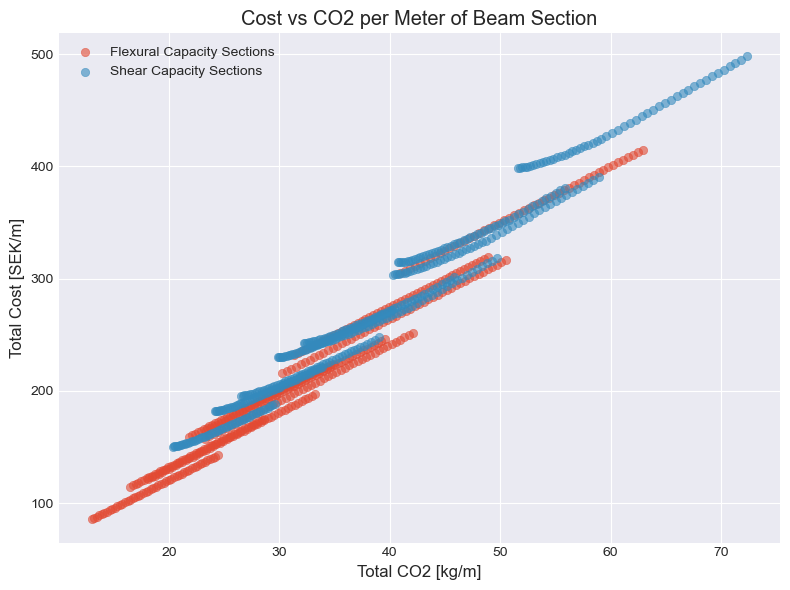

In [61]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 6))

# Flexural capacity points
plt.scatter(
    sectional_capacity["Total CO2 [kg/m]"],
    sectional_capacity["Total cost [SEK/m]"],
    alpha=0.6,
    label="Flexural Capacity Sections"
)

# Shear capacity points
plt.scatter(
    sectional_shear_capacity["Total CO2 [kg/m]"],
    sectional_shear_capacity["Total cost [SEK/m]"],
    alpha=0.6,
    label="Shear Capacity Sections"
)

# Labels and styling
plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total Cost [SEK/m]")
plt.title("Cost vs CO2 per Meter of Beam Section")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


## Add histograms to the cost-versus-CO2 plot

This block creates a more informative visualization by combining:
- a central scatter plot
- a top histogram for CO2 values
- a right-side histogram for cost values

The scatter plot shows the relationship between cost and CO2, while the histograms show how the data are distributed along each axis.

This helps us not only see individual design points, but also understand where most designs are concentrated and whether the two datasets have different overall patterns.

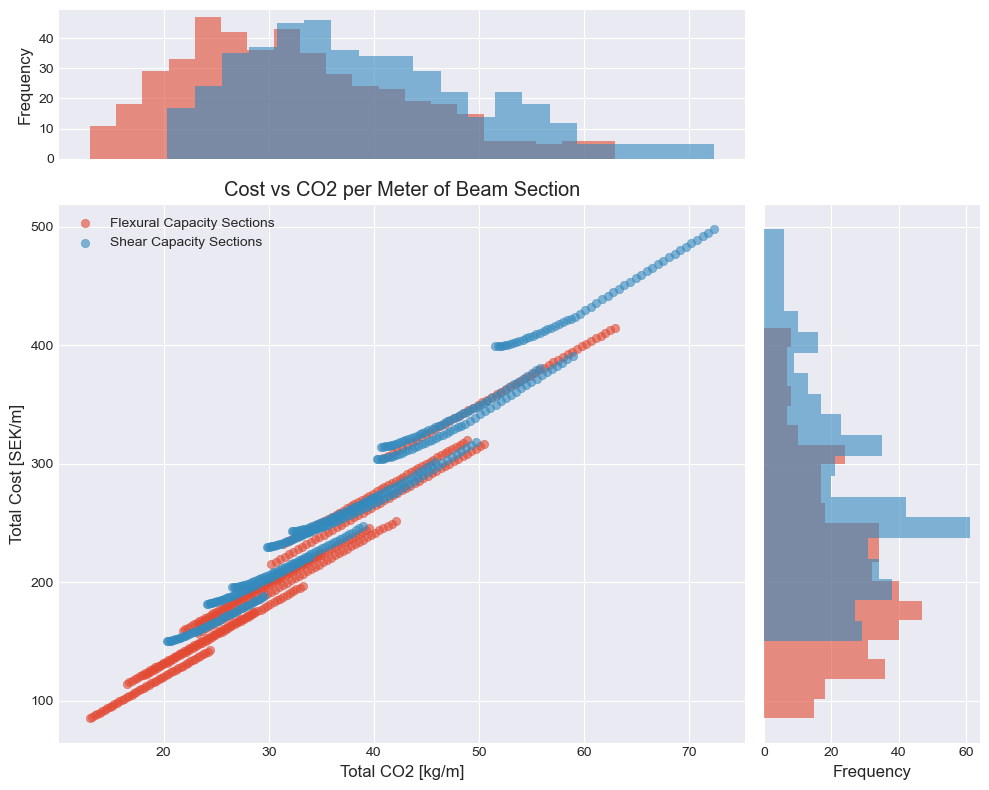

In [62]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Extract data
x1 = sectional_capacity["Total CO2 [kg/m]"]
y1 = sectional_capacity["Total cost [SEK/m]"]

x2 = sectional_shear_capacity["Total CO2 [kg/m]"]
y2 = sectional_shear_capacity["Total cost [SEK/m]"]

# Create figure layout
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(4, 4, figure=fig)

# Define axes
ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_histx   = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

# -----------------------
# Scatter plot (center)
# -----------------------
ax_scatter.scatter(x1, y1, alpha=0.6, label="Flexural Capacity Sections")
ax_scatter.scatter(x2, y2, alpha=0.6, label="Shear Capacity Sections")

ax_scatter.set_xlabel("Total CO2 [kg/m]")
ax_scatter.set_ylabel("Total Cost [SEK/m]")
ax_scatter.set_title("Cost vs CO2 per Meter of Beam Section")
ax_scatter.grid(True)
ax_scatter.legend()

# -----------------------
# Top histogram (CO2)
# -----------------------
ax_histx.hist(x1, bins=20, alpha=0.6)
ax_histx.hist(x2, bins=20, alpha=0.6)
ax_histx.set_ylabel("Frequency")
ax_histx.grid(True)

# Hide x-axis labels for top histogram
plt.setp(ax_histx.get_xticklabels(), visible=False)

# -----------------------
# Right histogram (Cost)
# -----------------------
ax_histy.hist(y1, bins=20, orientation='horizontal', alpha=0.6)
ax_histy.hist(y2, bins=20, orientation='horizontal', alpha=0.6)
ax_histy.set_xlabel("Frequency")
ax_histy.grid(True)

# Hide y-axis labels for right histogram
plt.setp(ax_histy.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()


## Add design actions from loading and self-weight

This code block introduces the structural demand that each beam must resist.

Using a chosen span and point load, the code calculates:
- self-weight of the beam from its concrete volume
- design bending moment at midspan
- design shear force at the support

These values are added directly to the existing dataframes.

This is an important transition in the notebook: up to now, the sections have only been described by their resistance. From this point on, they can also be checked against actual design demand.

In [63]:
# ============================================================
# 6. Design actions for chosen spans
# Adds new columns directly to the existing dataframes
# ============================================================

import pandas as pd

# USER INPUTS
P_kN = 100.0
#P_9m_kN = 100.0
gamma_concrete_kN_m3 = 25.0

L_m = 3.0
#L_9m = 9.0

def add_design_actions_inplace(df):
    # self weight [kN/m]
    df["Self weight [kN/m]"] = pd.to_numeric(df["Concrete vol [m3/m]"], errors="coerce") * gamma_concrete_kN_m3

    # midspan design moment [kNm]
    df["M_Ed,mid [kNm]"] = df["Self weight [kN/m]"] * L_m**2 / 8.0 + P_kN * L_m / 4.0
    #df["M_Ed,mid,9m [kNm]"] = df["Self weight [kN/m]"] * L_9m**2 / 8.0 + P_9m_kN * L_9m / 4.0

    # support shear [kN]
    df["V_Ed [kN]"] = df["Self weight [kN/m]"] * L_m / 2.0 + P_kN / 2.0
    #df["V_Ed,9m [kN]"] = df["Self weight [kN/m]"] * L_9m / 2.0 + P_9m_kN / 2.0

# modify the existing dataframes directly
add_design_actions_inplace(sectional_capacity)
add_design_actions_inplace(sectional_shear_capacity)

# Show results
print(f"Rows in sectional_shear_capacity: {len(sectional_shear_capacity)}")
sectional_shear_capacity
print(f"Number of rows in sectional_capacity: {len(sectional_capacity)}")
sectional_capacity

Rows in sectional_shear_capacity: 450
Number of rows in sectional_capacity: 450


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Section ID,...,Long steel CO2 [kg/m],Stirrups mass [kg/m],Stirrups cost [SEK/m],Stirrups CO2 [kg/m],Total steel mass [kg/m],Total cost [SEK/m],Total CO2 [kg/m],Self weight [kN/m],"M_Ed,mid [kNm]",V_Ed [kN]
0,1,1,25,,16,,434.782609,35,12,1,...,5.366343,0.0,0.0,0.0,3.156672,85.450084,12.986343,0.635000,75.714375,50.952500
1,1,1,25,,16,,434.782609,35,12,2,...,8.049514,0.0,0.0,0.0,4.735008,121.425127,18.129514,0.840000,75.945000,51.260000
2,1,1,25,,16,,434.782609,35,12,3,...,10.732686,0.0,0.0,0.0,6.313345,157.400169,23.272686,1.045000,76.175625,51.567500
3,1,1,25,,16,,434.782609,35,12,4,...,5.366343,0.0,0.0,0.0,3.156672,86.616411,13.219608,0.654439,75.736244,50.981658
4,1,1,25,,16,,434.782609,35,12,5,...,8.049514,0.0,0.0,0.0,4.735008,122.967984,18.438086,0.865714,75.973929,51.298571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,3,1,25,,25,,434.782609,35,12,446,...,19.652135,0.0,0.0,0.0,11.560079,317.860372,48.543971,2.407653,77.708610,53.611480
446,3,1,25,,25,,434.782609,35,12,447,...,26.202846,0.0,0.0,0.0,15.413439,412.701584,62.502846,3.025000,78.403125,54.537500
447,3,1,25,,25,,434.782609,35,12,448,...,13.101423,0.0,0.0,0.0,7.706719,224.350792,34.851423,1.812500,77.039062,52.718750
448,3,1,25,,25,,434.782609,35,12,449,...,19.652135,0.0,0.0,0.0,11.560079,319.651188,48.902135,2.437500,77.742188,53.656250


## Separate feasible and non-feasible sections for bending

This block compares flexural capacity with the required bending demand for a chosen span.

It splits the beam sections into two groups:
- feasible sections, where resistance is greater than or equal to demand
- non-feasible sections, where resistance is lower than demand

Then it plots both groups in a cost-versus-CO2 diagram with marginal histograms.

This makes it easier to see how structural feasibility affects the design space, and whether the feasible beam sections tend to cluster in a particular cost or CO2 range.

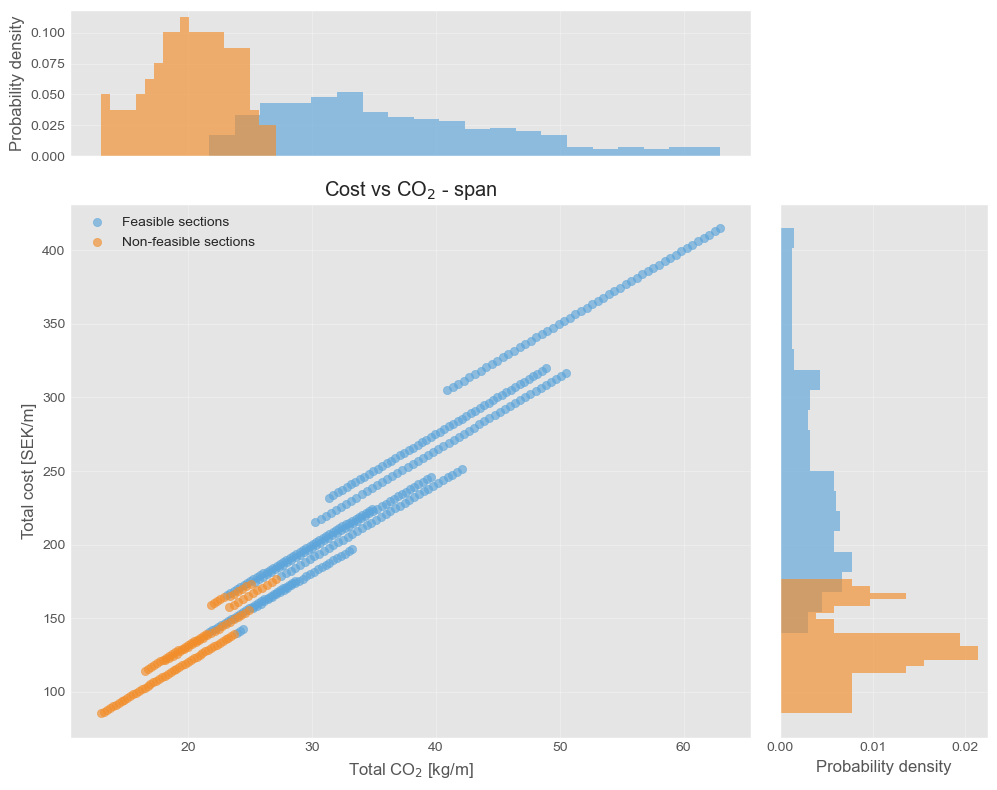

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.style.use("ggplot")

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
cost_col = "Total cost [SEK/m]"
co2_col = "Total CO2 [kg/m]"
moment_capacity_col = "M_Rd [kNm]"
med_8_col = "M_Ed,mid [kNm]"

# Colors similar to your reference
feasible_color = "#5DA5DA"
nonfeasible_color = "#F28E2B"

# -------------------------------------------------
# SPLIT FEASIBLE / NON-FEASIBLE
# -------------------------------------------------
feasible_8 = sectional_capacity[sectional_capacity[moment_capacity_col] >= sectional_capacity[med_8_col]].copy()
nonfeasible_8 = sectional_capacity[sectional_capacity[moment_capacity_col] < sectional_capacity[med_8_col]].copy()

# -------------------------------------------------
# EXTRACT DATA
# -------------------------------------------------
x_feas = feasible_8[co2_col]
y_feas = feasible_8[cost_col]

x_non = nonfeasible_8[co2_col]
y_non = nonfeasible_8[cost_col]

# -------------------------------------------------
# CREATE FIGURE LAYOUT
# -------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(4, 4, figure=fig)

ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_histx   = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

# -------------------------------------------------
# SCATTER PLOT
# -------------------------------------------------
ax_scatter.scatter(
    x_feas, y_feas,
    alpha=0.65, s=35,
    color=feasible_color,
    label="Feasible sections"
)

ax_scatter.scatter(
    x_non, y_non,
    alpha=0.65, s=35,
    color=nonfeasible_color,
    label="Non-feasible sections"
)

ax_scatter.set_xlabel("Total CO$_2$ [kg/m]")
ax_scatter.set_ylabel("Total cost [SEK/m]")
ax_scatter.set_title("Cost vs CO$_2$ - span")
ax_scatter.grid(True, alpha=0.3)
ax_scatter.legend()

# -------------------------------------------------
# TOP HISTOGRAM
# -------------------------------------------------
ax_histx.hist(
    x_feas,
    bins=20,
    density=True,
    alpha=0.65,
    color=feasible_color
)

ax_histx.hist(
    x_non,
    bins=20,
    density=True,
    alpha=0.65,
    color=nonfeasible_color
)

ax_histx.set_ylabel("Probability density")
ax_histx.grid(True, alpha=0.3)
plt.setp(ax_histx.get_xticklabels(), visible=False)

# -------------------------------------------------
# RIGHT HISTOGRAM
# -------------------------------------------------
ax_histy.hist(
    y_feas,
    bins=20,
    density=True,
    orientation="horizontal",
    alpha=0.65,
    color=feasible_color
)

ax_histy.hist(
    y_non,
    bins=20,
    density=True,
    orientation="horizontal",
    alpha=0.65,
    color=nonfeasible_color
)

ax_histy.set_xlabel("Probability density")
ax_histy.grid(True, alpha=0.3)
plt.setp(ax_histy.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()

## Plot normalised cost and normalised CO2 for feasible and non-feasible designs

This code block takes the previous comparison one step further by normalising cost and CO2.

The idea is to express every design relative to the best feasible values:
- normalised cost = cost divided by the minimum feasible cost
- normalised CO2 = CO2 divided by the minimum feasible CO2

This makes the results easier to compare on a common scale and highlights how far each design is from the best-performing feasible alternatives.

The plot again separates feasible and non-feasible sections, but now in a dimensionless form that is especially useful for comparing trade-offs between economy and environmental impact.

Note: this cell also uses the demand column `M_Ed,mid,8m [kNm]`, so it may need the same column-name adjustment as the previous cell.

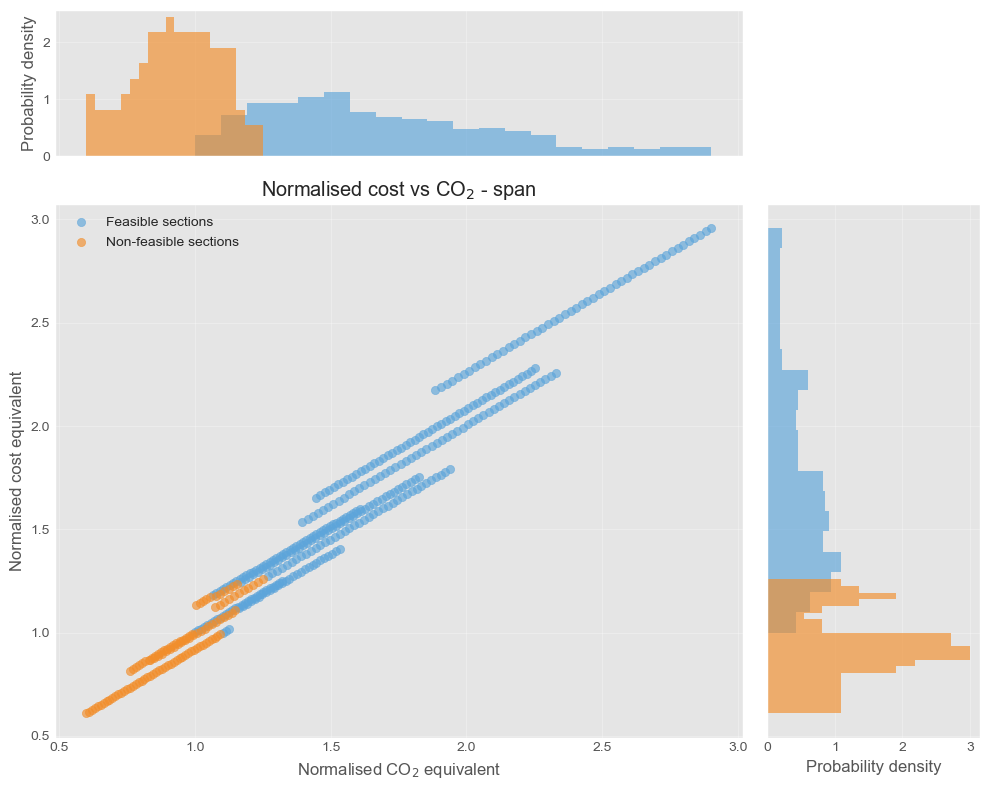

Best feasible cost = 140.267 SEK/m
Best feasible CO2  = 21.692 kg/m


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.style.use("ggplot")

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
cost_col = "Total cost [SEK/m]"
co2_col = "Total CO2 [kg/m]"
moment_capacity_col = "M_Rd [kNm]"
med_8_col = "M_Ed,mid [kNm]"

# Colors similar to your reference
feasible_color = "#5DA5DA"
nonfeasible_color = "#F28E2B"

# -------------------------------------------------
# PREPARE NORMALIZED DATA FOR 8 m ONLY
# -------------------------------------------------
def prepare_normalized_moment_data(df, demand_col):
    feasible = df[df[moment_capacity_col] >= df[demand_col]].copy()
    nonfeasible = df[df[moment_capacity_col] < df[demand_col]].copy()

    if feasible.empty:
        raise ValueError(f"No feasible solutions found for {demand_col}")

    best_cost = feasible[cost_col].min()
    best_co2 = feasible[co2_col].min()

    feasible["Normalized cost"] = feasible[cost_col] / best_cost
    feasible["Normalized CO2"] = feasible[co2_col] / best_co2

    nonfeasible["Normalized cost"] = nonfeasible[cost_col] / best_cost
    nonfeasible["Normalized CO2"] = nonfeasible[co2_col] / best_co2

    return feasible, nonfeasible, best_cost, best_co2


# -------------------------------------------------
# PLOT FUNCTION
# -------------------------------------------------
def plot_normalized_scatter_with_marginals(feasible_df, nonfeasible_df):
    x_feas = feasible_df["Normalized CO2"]
    y_feas = feasible_df["Normalized cost"]

    x_non = nonfeasible_df["Normalized CO2"]
    y_non = nonfeasible_df["Normalized cost"]

    fig = plt.figure(figsize=(10, 8))
    gs = GridSpec(4, 4, figure=fig)

    ax_scatter = fig.add_subplot(gs[1:4, 0:3])
    ax_histx   = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
    ax_histy   = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

    # Scatter
    ax_scatter.scatter(
        x_feas, y_feas,
        alpha=0.65, s=35,
        color=feasible_color,
        label="Feasible sections"
    )
    ax_scatter.scatter(
        x_non, y_non,
        alpha=0.65, s=35,
        color=nonfeasible_color,
        label="Non-feasible sections"
    )

    ax_scatter.set_xlabel("Normalised CO$_2$ equivalent")
    ax_scatter.set_ylabel("Normalised cost equivalent")
    ax_scatter.set_title("Normalised cost vs CO$_2$ - span")
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend()

    # Top histogram
    ax_histx.hist(
        x_feas,
        bins=20,
        density=True,
        alpha=0.65,
        color=feasible_color
    )
    ax_histx.hist(
        x_non,
        bins=20,
        density=True,
        alpha=0.65,
        color=nonfeasible_color
    )
    ax_histx.set_ylabel("Probability density")
    ax_histx.grid(True, alpha=0.3)
    plt.setp(ax_histx.get_xticklabels(), visible=False)

    # Right histogram
    ax_histy.hist(
        y_feas,
        bins=20,
        density=True,
        orientation="horizontal",
        alpha=0.65,
        color=feasible_color
    )
    ax_histy.hist(
        y_non,
        bins=20,
        density=True,
        orientation="horizontal",
        alpha=0.65,
        color=nonfeasible_color
    )
    ax_histy.set_xlabel("Probability density")
    ax_histy.grid(True, alpha=0.3)
    plt.setp(ax_histy.get_yticklabels(), visible=False)

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Plot normalized scatter with marginals
# -------------------------------------------------
feasible_8, nonfeasible_8, best_cost_8, best_co2_8 = prepare_normalized_moment_data(
    sectional_capacity, med_8_col
)

plot_normalized_scatter_with_marginals(feasible_8, nonfeasible_8)

print(f"Best feasible cost = {best_cost_8:.3f} SEK/m")
print(f"Best feasible CO2  = {best_co2_8:.3f} kg/m")

## Compare the lowest-CO2 feasible solution with the average feasible design

This code block performs a statistical comparison within the feasible set of designs.

It first keeps only the feasible beam sections and then selects all numerical variables that can be compared fairly. These variables are normalised using min-max scaling.

After that, the code identifies:
- the feasible solution with the lowest CO2
- the average location of all feasible solutions in the normalised design space

A comparison table is then built to show which variables differ the most between the lowest-CO2 solution and the average feasible design.

This helps reveal what makes the most climate-efficient design special compared with a more typical feasible beam section.

In [69]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Use the feasible set already created
# ------------------------------------------------------------
df = feasible_8.copy()

# ------------------------------------------------------------
# Select numeric columns for normalised comparison
# ------------------------------------------------------------
exclude_cols = {"Feasible", "feasible"}
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
compare_cols = [c for c in numeric_cols if c not in exclude_cols]

# ------------------------------------------------------------
# Normalise feasible solutions
# ------------------------------------------------------------
mins = df[compare_cols].min()
maxs = df[compare_cols].max()
ranges = (maxs - mins).replace(0, 1.0)

df_norm = (df[compare_cols] - mins) / ranges
mean_feasible_norm = df_norm.mean()

# ------------------------------------------------------------
# Lowest-CO2 feasible solution
# ------------------------------------------------------------
idx_lowest_co2 = df["Total CO2 [kg/m]"].idxmin()
row_lowest_co2 = df.loc[idx_lowest_co2]

# ------------------------------------------------------------
# Feasible solution closest to the mean
# ------------------------------------------------------------
distances = np.sqrt(((df_norm - mean_feasible_norm) ** 2).sum(axis=1))
idx_closest_to_mean = distances.idxmin()
row_closest_to_mean = df.loc[idx_closest_to_mean]

# ------------------------------------------------------------
# Print both in the same style
# ------------------------------------------------------------
print("--- RAW VALUES FOR LOWEST-CO2 FEASIBLE SOLUTION ---")
print(row_lowest_co2[
    ["Total CO2 [kg/m]", "Total cost [SEK/m]", "M_Rd [kNm]", "M_Ed,mid [kNm]"]
])

print("\n--- RAW VALUES FOR FEASIBLE SOLUTION CLOSEST TO THE MEAN ---")
print(row_closest_to_mean[
    ["Total CO2 [kg/m]", "Total cost [SEK/m]", "M_Rd [kNm]", "M_Ed,mid [kNm]"]
])

# ------------------------------------------------------------
# Side-by-side comparison table
# ------------------------------------------------------------
comparison_table = pd.DataFrame({
    "Lowest-CO2 feasible": row_lowest_co2[
        ["Total CO2 [kg/m]", "Total cost [SEK/m]", "M_Rd [kNm]", "M_Ed,mid [kNm]"]
    ],
    "Closest-to-mean feasible": row_closest_to_mean[
        ["Total CO2 [kg/m]", "Total cost [SEK/m]", "M_Rd [kNm]", "M_Ed,mid [kNm]"]
    ]
})

print("\n--- SIDE-BY-SIDE COMPARISON ---")
display(comparison_table)

print(f"Distance of closest-to-mean solution to mean normalised feasible solution: {distances.loc[idx_closest_to_mean]:.4f}")

--- RAW VALUES FOR LOWEST-CO2 FEASIBLE SOLUTION ---
Total CO2 [kg/m]       21.692054
Total cost [SEK/m]    140.520221
M_Rd [kNm]             76.868976
M_Ed,mid [kNm]         76.247545
Name: 213, dtype: object

--- RAW VALUES FOR FEASIBLE SOLUTION CLOSEST TO THE MEAN ---
Total CO2 [kg/m]       33.295734
Total cost [SEK/m]    214.568597
M_Rd [kNm]            137.774762
M_Ed,mid [kNm]         76.942347
Name: 241, dtype: object

--- SIDE-BY-SIDE COMPARISON ---


,Lowest-CO2 feasible,Closest-to-mean feasible
Total CO2 [kg/m],21.692054,33.295734
Total cost [SEK/m],140.520221,214.568597
M_Rd [kNm],76.868976,137.774762
"M_Ed,mid [kNm]",76.247545,76.942347


Distance of closest-to-mean solution to mean normalised feasible solution: 0.4896


## Highlight two important feasible solutions in a cost-versus-CO2 plot

This final code block visualises the feasible design space and highlights two special beam sections:
- the feasible solution with the lowest CO2
- the feasible solution closest to the mean of all feasible designs

All feasible designs are plotted first, and then the two reference points are marked with larger symbols and labels.

This makes it easier to interpret the results visually:
- one point represents the most climate-efficient feasible solution
- the other represents a more central, typical feasible solution

Together, these highlighted points help support discussion about whether a final design should be chosen for optimal environmental performance or for being more representative of the full feasible design space.

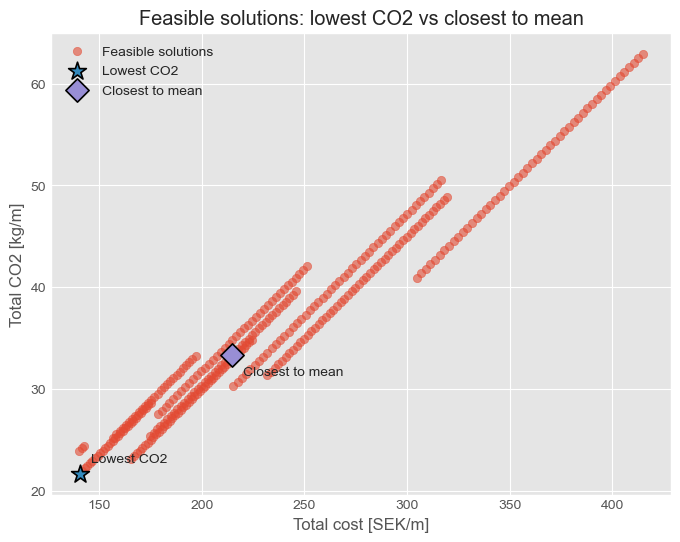

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Recreate both reference points from feasible solutions
# ------------------------------------------------------------
df = feasible_8.copy()

exclude_cols = {"Feasible", "feasible"}
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
compare_cols = [c for c in numeric_cols if c not in exclude_cols]

mins = df[compare_cols].min()
maxs = df[compare_cols].max()
ranges = (maxs - mins).replace(0, 1.0)

df_norm = (df[compare_cols] - mins) / ranges
mean_feasible_norm = df_norm.mean()

# Lowest-CO2 feasible solution
idx_lowest_co2 = df["Total CO2 [kg/m]"].idxmin()
row_lowest_co2 = df.loc[idx_lowest_co2]

# Closest-to-mean feasible solution
distances = np.sqrt(((df_norm - mean_feasible_norm) ** 2).sum(axis=1))
idx_closest_to_mean = distances.idxmin()
row_closest_to_mean = df.loc[idx_closest_to_mean]

# ------------------------------------------------------------
# Plot: all feasible solutions + highlighted comparison points
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Total cost [SEK/m]"],
    df["Total CO2 [kg/m]"],
    alpha=0.6,
    label="Feasible solutions"
)

plt.scatter(
    row_lowest_co2["Total cost [SEK/m]"],
    row_lowest_co2["Total CO2 [kg/m]"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.2,
    label="Lowest CO2"
)

plt.scatter(
    row_closest_to_mean["Total cost [SEK/m]"],
    row_closest_to_mean["Total CO2 [kg/m]"],
    s=140,
    marker="D",
    edgecolors="black",
    linewidths=1.2,
    label="Closest to mean"
)

plt.annotate(
    "Lowest CO2",
    (
        row_lowest_co2["Total cost [SEK/m]"],
        row_lowest_co2["Total CO2 [kg/m]"]
    ),
    xytext=(8, 8),
    textcoords="offset points"
)

plt.annotate(
    "Closest to mean",
    (
        row_closest_to_mean["Total cost [SEK/m]"],
        row_closest_to_mean["Total CO2 [kg/m]"]
    ),
    xytext=(8, -14),
    textcoords="offset points"
)

plt.xlabel("Total cost [SEK/m]")
plt.ylabel("Total CO2 [kg/m]")
plt.title("Feasible solutions: lowest CO2 vs closest to mean")
plt.grid(True)
plt.legend()
plt.show()